In [2]:
import os
import sys
from pathlib import Path

# Get the correct project directory
project_dir = r'c:\Users\HP\Desktop\InsightHire'

# Change to the correct project directory
os.chdir(project_dir)

print("Project directory:", os.getcwd())
print("Files in project:", os.listdir('.'))

# Add to Python path
sys.path.insert(0, project_dir)

# Now import and load
from src.data_loader.candidate_loader import CandidateLoader

loader = CandidateLoader()
candidates = loader.load_candidates()
print(f"Loaded {len(candidates)} candidates")


Project directory: c:\Users\HP\Desktop\InsightHire
Files in project: ['.git', '.gitignore', 'Data', 'load_candidates.py', 'models', 'notebooks', 'outputs', 'README.md', 'src']


INFO:src.data_loader.candidate_loader:Loaded 100000 candidates


Loaded 100000 candidates


In [3]:
total_candidates = len(candidates)
print(total_candidates)

100000


In [4]:
# Now we will count the skills for each candidate because it will help us to understand the distribution of skills and also we will identify the candidates with rare skills so it will help us in rankings also

# Extract all skills from all candidates
all_skills = []
for candidate in candidates:
    for skill in candidate['skills']:
        all_skills.append(skill['name'])

# Count frequency
from collections import Counter
skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(20)  # Top 20 skills

for skill,count in top_skills:
    print(f"{skill}: {count}")
    



HTML: 12246
Databricks: 12244
Redux: 12222
Terraform: 12187
Angular: 12173
Figma: 12157
Salesforce CRM: 12157
Vue.js: 12142
Sales: 12138
Accounting: 12136
Agile: 12135
Kafka: 12114
Excel: 12109
BigQuery: 12108
CI/CD: 12108
Project Management: 12106
Airflow: 12105
AWS: 12104
Flask: 12104
Scrum: 12083


In [5]:
# experience distribution

experience_years = []

for candidate in candidates:
    exp = candidate['profile']['years_of_experience']
    experience_years.append(exp)

import numpy as np

print(f"Average experience: {np.mean(experience_years)} years")
print(f"Median experience: {np.median(experience_years)} years")
print(f"Minimum experience: {min(experience_years)} years")
print(f"Maximum experience: {max(experience_years)} years")


Average experience: 7.166318999999999 years
Median experience: 6.8 years
Minimum experience: 1.0 years
Maximum experience: 16.9 years


In [6]:
# Current Title analysis

titles = []

for candidate in candidates:
    title = candidate['profile']['current_title']
    titles.append(title)

from collections import Counter
title_counts = Counter(titles)
top_titles = title_counts.most_common(15)
for i, (title, count) in enumerate(top_titles, 1):
    percentage = (count / len(candidates)) * 100
    print(f"{i:2d}. {title}: {count:,} candidates ({percentage:.1f}%)")
    

 1. Business Analyst: 5,833 candidates (5.8%)
 2. HR Manager: 5,830 candidates (5.8%)
 3. Mechanical Engineer: 5,791 candidates (5.8%)
 4. Accountant: 5,764 candidates (5.8%)
 5. Project Manager: 5,754 candidates (5.8%)
 6. Customer Support: 5,750 candidates (5.8%)
 7. Operations Manager: 5,744 candidates (5.7%)
 8. Content Writer: 5,727 candidates (5.7%)
 9. Sales Executive: 5,713 candidates (5.7%)
10. Civil Engineer: 5,702 candidates (5.7%)
11. Graphic Designer: 5,689 candidates (5.7%)
12. Marketing Manager: 5,524 candidates (5.5%)
13. Software Engineer: 3,450 candidates (3.5%)
14. Full Stack Developer: 2,873 candidates (2.9%)
15. Cloud Engineer: 2,836 candidates (2.8%)


In [7]:
# company analysis

companies = []

for candidate in candidates:
    company = candidate['profile']['current_company']
    companies.append(company)
company_counts = Counter(companies)
top_companies = company_counts.most_common(15)
for i, (company, count) in enumerate(top_companies, 1):
    percentage = (count / len(candidates)) * 100
    print(f"{i:2d}. {company}: {count:,} candidates ({percentage:.1f}%)")

tech_giants = ['Google', 'Microsoft', 'Amazon', 'Apple', 'Meta', 'Netflix', 'Tesla']
print(f"\n--- TECH GIANTS ANALYSIS ---")
tech_total = 0
for company in tech_giants:
    count = company_counts.get(company, 0)  # .get() returns 0 if not found
    if count > 0:
        percentage = (count / len(candidates)) * 100
        print(f"{company}: {count:,} candidates ({percentage:.1f}%)")
        tech_total += count

print(f"\nTotal from tech giants: {tech_total:,} ({(tech_total/len(candidates))*100:.1f}%)")

 1. Infosys: 7,590 candidates (7.6%)
 2. Wayne Enterprises: 7,571 candidates (7.6%)
 3. Wipro: 7,566 candidates (7.6%)
 4. Initech: 7,528 candidates (7.5%)
 5. Pied Piper: 7,500 candidates (7.5%)
 6. Globex Inc: 7,492 candidates (7.5%)
 7. Acme Corp: 7,490 candidates (7.5%)
 8. Dunder Mifflin: 7,467 candidates (7.5%)
 9. TCS: 7,451 candidates (7.5%)
10. Hooli: 7,378 candidates (7.4%)
11. Stark Industries: 7,323 candidates (7.3%)
12. Swiggy: 1,288 candidates (1.3%)
13. Accenture: 1,274 candidates (1.3%)
14. Capgemini: 1,265 candidates (1.3%)
15. CRED: 1,257 candidates (1.3%)

--- TECH GIANTS ANALYSIS ---
Google: 6 candidates (0.0%)
Microsoft: 5 candidates (0.0%)
Amazon: 5 candidates (0.0%)
Apple: 2 candidates (0.0%)
Meta: 7 candidates (0.0%)
Netflix: 6 candidates (0.0%)

Total from tech giants: 31 (0.0%)


In [8]:
# Behaviourial signal analysis

# Extract behavioural signals

github_scores = []
response_rates = []
notice_periods = []
profile_completeness = []
aplication_30_days = []

for candidate in candidates:
    signals = candidate['redrob_signals']
    github_scores.append(signals['github_activity_score'])
    response_rates.append(signals['recruiter_response_rate'])
    notice_periods.append(signals['notice_period_days'])
    profile_completeness.append(signals['profile_completeness_score'])
    aplication_30_days.append(signals['applications_submitted_30d'])

print(f"\n - Github ANALYSIS -")    
github_valid = [score for score in github_scores if score != -1]
github_none_count = len([score for score in github_scores if score == -1])

print(f"Candidates with GitHub: {len(github_valid):,} ({(len(github_valid)/len(candidates))*100:.1f}%)")
print(f"Candidates without GitHub: {github_none_count:,} ({(github_none_count/len(candidates))*100:.1f}%)")

if github_valid:  # Only calculate if there are GitHub users
    import numpy as np
    print(f"Average GitHub activity score: {np.mean(github_valid):.1f}")
    print(f"Highest GitHub activity: {max(github_valid)}")
    
    # High GitHub activity (>50 is usually good)
    high_github = len([score for score in github_valid if score > 50])
    print(f"High GitHub activity (>50): {high_github:,} ({(high_github/len(candidates))*100:.1f}%)")

# 2. Response Rate Analysis  
print(f"\n - RECRUITER RESPONSE ANALYSIS -")
print(f"Average response rate: {np.mean(response_rates):.2f} ({np.mean(response_rates)*100:.1f}%)")
print(f"Highest response rate: {max(response_rates):.2f}")

# High responders (>70% response rate = very engaged)
high_responders = len([rate for rate in response_rates if rate > 0.7])
print(f"High responders (>70%): {high_responders:,} ({(high_responders/len(candidates))*100:.1f}%)")

# 3. Notice Period Analysis
print(f"\n - AVAILABILITY ANALYSIS -")
print(f"Average notice period: {np.mean(notice_periods):.1f} days")
print(f"Shortest notice: {min(notice_periods)} days")
print(f"Longest notice: {max(notice_periods)} days")

# Quick joiners (≤30 days notice)
quick_joiners = len([days for days in notice_periods if days <= 30])
print(f"Quick joiners (≤30 days): {quick_joiners:,} ({(quick_joiners/len(candidates))*100:.1f}%)")

# 4. Profile Quality Analysis
print(f"\n - PROFILE QUALITY ANALYSIS -")
print(f"Average profile completeness: {np.mean(profile_completeness):.1f}%")
high_quality_profiles = len([score for score in profile_completeness if score > 80])
print(f"High quality profiles (>80%): {high_quality_profiles:,} ({(high_quality_profiles/len(candidates))*100:.1f}%)")


 - Github ANALYSIS -
Candidates with GitHub: 35,363 (35.4%)
Candidates without GitHub: 64,637 (64.6%)
Average GitHub activity score: 29.0
Highest GitHub activity: 96.9
High GitHub activity (>50): 3,917 (3.9%)

 - RECRUITER RESPONSE ANALYSIS -
Average response rate: 0.44 (43.7%)
Highest response rate: 0.95
High responders (>70%): 13,240 (13.2%)

 - AVAILABILITY ANALYSIS -
Average notice period: 87.4 days
Shortest notice: 0 days
Longest notice: 150 days
Quick joiners (≤30 days): 13,809 (13.8%)

 - PROFILE QUALITY ANALYSIS -
Average profile completeness: 56.8%
High quality profiles (>80%): 10,613 (10.6%)


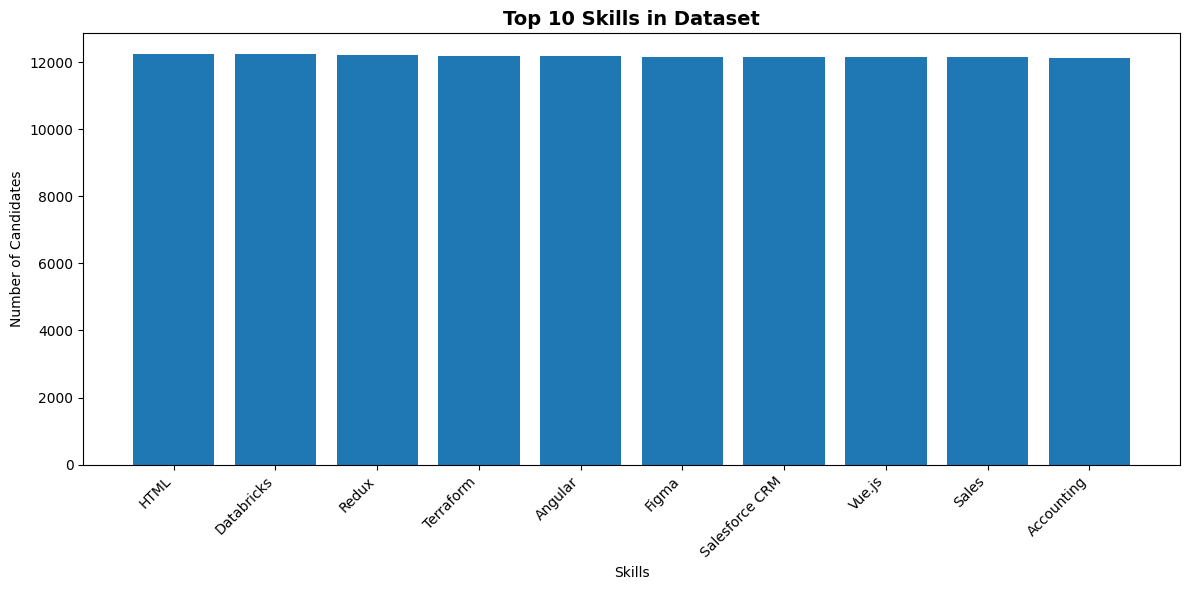

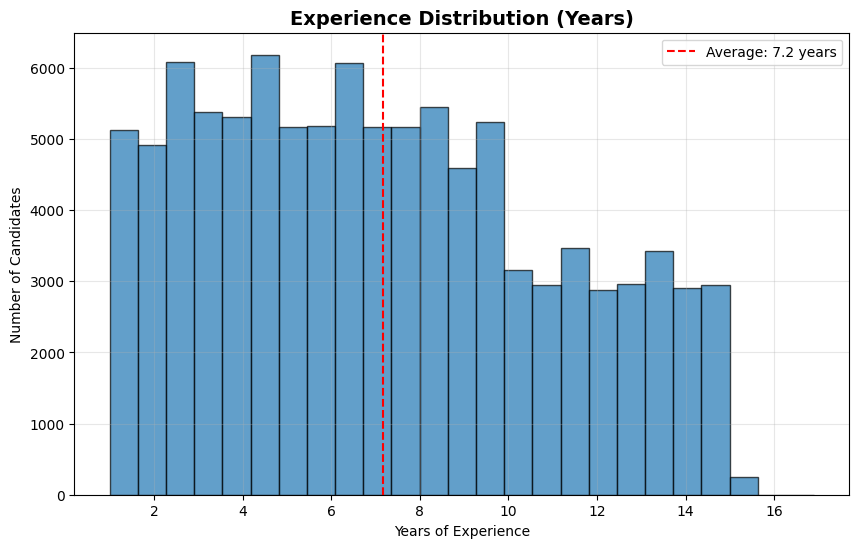

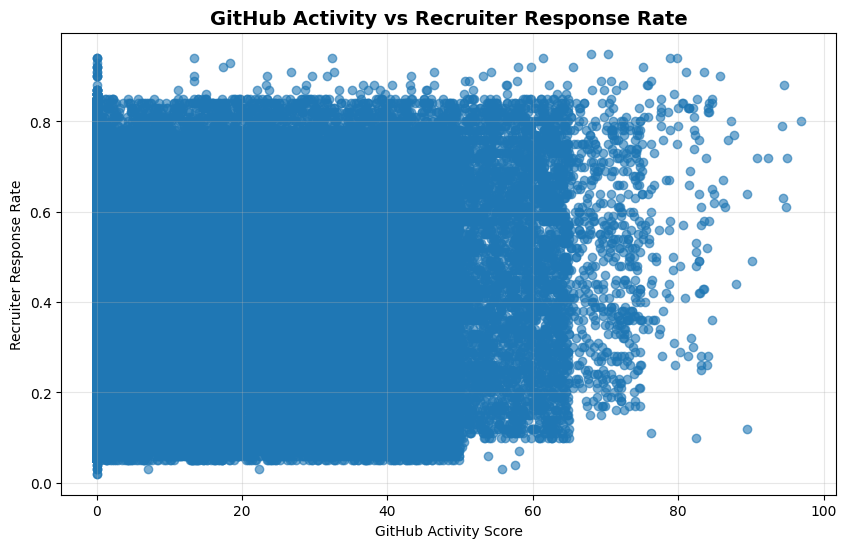

In [10]:
# G) Create Visualizations
import matplotlib.pyplot as plt



# 1. Top Skills Chart
plt.figure(figsize=(12, 6))
skills_names = [skill for skill, count in top_skills[:10]]
skills_counts = [count for skill, count in top_skills[:10]]

plt.bar(skills_names, skills_counts)
plt.title('Top 10 Skills in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Skills')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Experience Distribution Histogram
plt.figure(figsize=(10, 6))
plt.hist(experience_years, bins=25, edgecolor='black', alpha=0.7)
plt.title('Experience Distribution (Years)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Number of Candidates')
plt.axvline(np.mean(experience_years), color='red', linestyle='--', 
           label=f'Average: {np.mean(experience_years):.1f} years')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. GitHub Activity vs Response Rate (Scatter plot)
if github_valid:
    plt.figure(figsize=(10, 6))
    # Only plot candidates who have GitHub
    github_for_plot = [score if score != -1 else 0 for score in github_scores]
    plt.scatter(github_for_plot, response_rates, alpha=0.6)
    plt.title('GitHub Activity vs Recruiter Response Rate', fontsize=14, fontweight='bold')
    plt.xlabel('GitHub Activity Score')
    plt.ylabel('Recruiter Response Rate')
    plt.grid(True, alpha=0.3)
    plt.show()




In [15]:
# H) Generate Learning Summary
print("📋 YOUR DATASET LEARNING SUMMARY")


print(f"""
🔢 BASIC STATISTICS:
   • Total candidates: {len(candidates):,}
   • Unique skills in dataset: {len(skill_counts):,}
   • Average experience: {np.mean(experience_years):.1f} years
   • Experience range: {min(experience_years)} - {max(experience_years)} years

🎯 AI/ML READINESS SIGNALS:
   • Candidates with GitHub accounts: {len(github_valid):,} ({(len(github_valid)/len(candidates))*100:.1f}%)
   • High GitHub activity (>50): {high_github:,} ({(high_github/len(candidates))*100:.1f}%)
   • High recruiter response rate (>70%): {high_responders:,} ({(high_responders/len(candidates))*100:.1f}%)
   • Quick availability (≤30 days): {quick_joiners:,} ({(quick_joiners/len(candidates))*100:.1f}%)
   • High-quality profiles (>80%): {high_quality_profiles:,} ({(high_quality_profiles/len(candidates))*100:.1f}%)

🏆 RANKING ALGORITHM INSIGHTS:
   1. GitHub activity = Strong technical signal (only {(len(github_valid)/len(candidates))*100:.1f}% have it!)
   2. Response rate = Job search engagement indicator  
   3. Notice period = Hiring speed factor
   4. Profile completeness = Attention to detail signal
   5. Experience sweet spot appears to be around {np.mean(experience_years):.1f} years
""")

# Top skills for AI/ML relevance
print("🛠️  TOP SKILLS TO WEIGHT IN RANKING:")
ai_ml_keywords = ['Python', 'Machine Learning', 'SQL', 'Deep Learning', 'AWS', 'Docker', 'Spark']
for skill, count in top_skills[:15]:
    if any(keyword.lower() in skill.lower() for keyword in ai_ml_keywords):
        percentage = (count / len(candidates)) * 100
        print(f"   • {skill}: {count:,} candidates ({percentage:.1f}%) ⭐")
    else:
        percentage = (count / len(candidates)) * 100
        print(f"   • {skill}: {count:,} candidates ({percentage:.1f}%)")




📋 YOUR DATASET LEARNING SUMMARY

🔢 BASIC STATISTICS:
   • Total candidates: 100,000
   • Unique skills in dataset: 133
   • Average experience: 7.2 years
   • Experience range: 1.0 - 16.9 years

🎯 AI/ML READINESS SIGNALS:
   • Candidates with GitHub accounts: 35,363 (35.4%)
   • High GitHub activity (>50): 3,917 (3.9%)
   • High recruiter response rate (>70%): 13,240 (13.2%)
   • Quick availability (≤30 days): 13,809 (13.8%)
   • High-quality profiles (>80%): 10,613 (10.6%)

🏆 RANKING ALGORITHM INSIGHTS:
   1. GitHub activity = Strong technical signal (only 35.4% have it!)
   2. Response rate = Job search engagement indicator  
   3. Notice period = Hiring speed factor
   4. Profile completeness = Attention to detail signal
   5. Experience sweet spot appears to be around 7.2 years

🛠️  TOP SKILLS TO WEIGHT IN RANKING:
   • HTML: 12,246 candidates (12.2%)
   • Databricks: 12,244 candidates (12.2%)
   • Redux: 12,222 candidates (12.2%)
   • Terraform: 12,187 candidates (12.2%)
   • Angu